In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Motif binding score (see analysis code for calculation)
binding_data_dir = "binding_score_at_motifs"
background_binding_dir = f"{binding_data_dir}/background_binding_arrays"

family_regex_search = ["__*loc-prom__*family*__fl25__*.csv"]

## Imports

In [3]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

## Sample Groups

In [4]:
# Keep only the sample groups used in the final plot
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]

## Data Loading

In [5]:
# Load one sample's motif scores and matched background scores
def load_sample(sample_name, regex_search):
    if len(regex_search) == 1:
        df_files = glob.glob(
            f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[0]}"
        )
    if len(regex_search) == 2:
        df_files = (
            glob.glob(f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[0]}")
            + glob.glob(f"{binding_data_dir}/{sample_name}/{sample_name}{regex_search[1]}")
        )
    if len(df_files) != 1:
        return None, None

    bg_files = glob.glob(
        f"{background_binding_dir}/{sample_name}__*__loc-prom__signal_bg__fl25*.npy"
    )
    if len(bg_files) != 1:
        return None, None

    df = pd.read_csv(df_files[0])
    z_bg = np.load(bg_files[0])[:, 1]
    return z_bg, df

## Helper Functions

In [6]:
# Convert background and motif z-scores into ROC curve coordinates
def roc_xy_from_z(z_bg, z_fg, n_points=10000, log_x=False, x_min=1e-5):
    z_bg = np.sort(np.asarray(z_bg, float))
    z_fg = np.sort(np.asarray(z_fg, float))
    if z_bg.size == 0 or z_fg.size == 0:
        return None, None

    if not log_x:
        qs = np.linspace(0.0, 1.0, n_points)
        thr = np.quantile(z_bg, qs)
        tmax = np.nextafter(max(z_bg.max(), z_fg.max()), np.inf)
        thr = np.r_[thr, tmax]

        x = (z_bg.size - np.searchsorted(z_bg, thr, "left")) / z_bg.size
        y = (z_fg.size - np.searchsorted(z_fg, thr, "left")) / z_fg.size

        x, y = x[::-1], y[::-1]
        return x, y

    x = np.logspace(np.log10(x_min), 0.0, n_points)
    qs = 1.0 - x
    qs = np.clip(qs, 0.0, 1.0)

    thr = np.quantile(z_bg, qs)
    tmax = np.nextafter(max(z_bg.max(), z_fg.max()), np.inf)
    thr = np.r_[thr, tmax]

    x_bg = (z_bg.size - np.searchsorted(z_bg, thr, "left")) / z_bg.size
    y = (z_fg.size - np.searchsorted(z_fg, thr, "left")) / z_fg.size

    return x_bg, y

## Plotting

[warn] skipping FOS: could not load sample
[warn] skipping CREB5: could not load sample


/tmp/ipykernel_3679557/1396822695.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


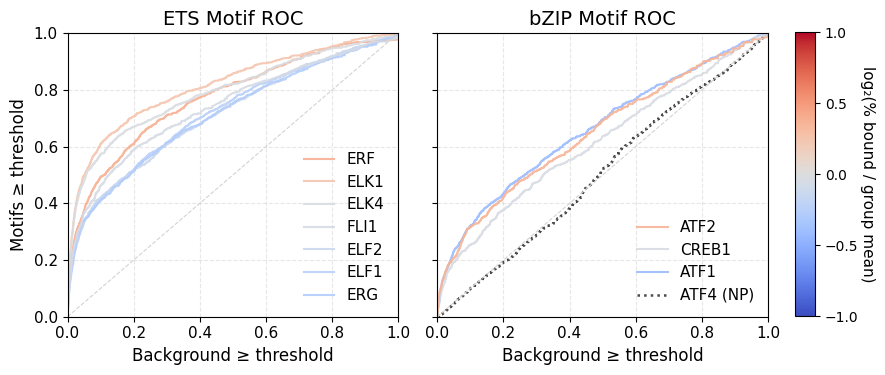

In [7]:
# Plot two ROC panels and color curves by relative percent bound
def plot_roc_two_groups(sample_list_1, title_1,
                        sample_list_2, title_2,
                        suptitle=None):
    fig, axes = plt.subplots(
        1, 2, figsize=(8, 4), sharey=True
    )

    for ax, sample_list, title in zip(
        axes,
        [sample_list_1, sample_list_2],
        [title_1, title_2],
    ):
        # Load all samples and compute the percent bound used for coloring
        data = []
        for s in sample_list:
            z_bg, df = load_sample(
                s,
                regex_search=family_regex_search,
            )
            if z_bg is None or df is None:
                print(f"[warn] skipping {s}: could not load sample")
                continue

            z_fg = pd.to_numeric(
                df["z_score"], errors="coerce"
            ).dropna().to_numpy()
            if z_fg.size == 0:
                print(f"[warn] skipping {s}: no valid z_score values")
                continue

            z_fg_norm = pd.to_numeric(
                df["z_score_norm_f7"], errors="coerce"
            ).dropna().to_numpy()
            if z_fg_norm.size == 0:
                print(f"[warn] skipping {s}: no valid normalized z_score values")
                continue

            pct = 100.0 * (z_fg_norm > 3).mean()
            data.append((s, z_bg, z_fg, pct))

        if len(data) == 0:
            print(f"[warn] no valid samples for '{title}'")
            continue

        # Map each curve color to log2(percent bound / group mean)
        pcts = np.array([pct for (s, _, _, pct) in data if s != "ATF4"], dtype=float)
        mean_pct = pcts.mean() if pcts.size > 0 else np.nan

        eps = 1e-9
        log2_rel = np.array(
            [
                np.nan if s == "ATF4" else np.log2((pct + eps) / (mean_pct + eps))
                for (s, _, _, pct) in data
            ],
            dtype=float
        )
        log2_rel = np.clip(log2_rel, -1.0, 1.0)

        cmap = plt.cm.coolwarm
        norm = mpl.colors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

        # Draw ROC curves
        for (s, z_bg, z_fg, _pct), v in zip(data, log2_rel):
            x, y = roc_xy_from_z(z_bg, z_fg)
            if x is None:
                print(f"[warn] skipping {s}: empty x/y")
                continue

            if s == "ATF4":
                label = "ATF4 (NP)"
                ax.plot(
                    x, y,
                    label=label,
                    color="0.25",
                    linestyle="dotted",
                    linewidth=1.8,
                    alpha=0.95,
                )
            else:
                label = "ERF" if s == "ERF1" else s
                ax.plot(
                    x, y,
                    label=label,
                    color=cmap(norm(v)),
                    linewidth=1.5,
                    alpha=0.9,
                )

        ax.plot([0, 1], [0, 1], "--", lw=0.8, color="lightgray")

        ax.set_title(title, fontsize=14)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_xlabel("Background ≥ threshold", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)

        # Order legend so the highest relative binding appears first
        handles, labels = ax.get_legend_handles_labels()
        order = np.argsort(np.nan_to_num(log2_rel, nan=-np.inf))[::-1]
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        ax.legend(
            handles, labels,
            frameon=False,
            fontsize=11,
            loc="lower right",
        )

    axes[0].set_ylabel("Motifs ≥ threshold", fontsize=12)

    # Add a shared colorbar to the right of the second panel
    cmap = plt.cm.coolwarm
    norm = mpl.colors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

    pos = axes[1].get_position()
    cax = fig.add_axes([
        pos.x1 + 0.1,
        pos.y0 + 0.05,
        0.025,
        pos.height - 0.06
    ])

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("log₂(% bound / group mean)", rotation=270, labelpad=12, fontsize=11)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])

    if suptitle is not None:
        fig.suptitle(suptitle, y=1.02)

    plt.tight_layout()
    plt.show()


plot_roc_two_groups(
    GABPA_WT, "ETS Motif ROC",
    BATF3_WT, "bZIP Motif ROC",
    suptitle=""
)